In [1]:
import numpy as np
import matplotlib.pyplot as plt 
from scipy.integrate import solve_ivp
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets,transforms
from torch.optim import lr_scheduler
import numpy as np
import time
import matplotlib
from matplotlib import pyplot as pp
import scipy
from scipy.integrate import solve_ivp
import random
import functools
import pickle

import pandas as pd
import functools
from scipy.optimize import curve_fit
from scipy import signal, optimize
import numpy as np
from scipy.fft import fft, fftfreq
import matplotlib.pyplot as plt
from scipy.linalg import lstsq

from scipy.linalg import inv
from scipy.optimize import fsolve
from scipy.optimize import least_squares
from scipy.stats import trim_mean
from scipy.fft import fft, fftfreq
from scipy.integrate import solve_ivp
import control as ct
from scipy.signal import csd, welch



data

In [2]:
def wrap_angle(x):
    """Wrap angle(s) in radians to (-pi, pi]."""
    return (x + np.pi) % (2 * np.pi) - np.pi

# Load the data and unpack columns into variables
t, V, alpha, gamma, Q, delta_T, delta_e = np.loadtxt(
    'flight_data.txt', 
    unpack=True
)

alpha   = np.radians(alpha)
gamma   = np.radians(gamma)
Q       = np.radians(Q)
delta_e = np.radians(delta_e)

#real parameters of aircraft
g=9.8; rho=1.225; S=0.25; cbar=0.2; m=1.2; Jy=0.05

# ── Load data (replace with your arrays) ──────────────────────────────
# t, V, alpha, gamma, Q, delta_T, delta_e

N  = len(t)
dt = t[1] - t[0]

def deriv(x): return np.gradient(x, dt)
def W(x):     return x * np.hanning(N)   # windowed FFT
def F(x):     return fft(W(x))

freqs = fftfreq(N, dt)

Vdot     = deriv(V)
alphadot = deriv(alpha)
gammadot = deriv(gamma)
Qdot     = deriv(Q)
qhat     = cbar * Q / (2 * V)
q_dyn    = 0.5 * rho * V**2




get trim point for linearization

In [3]:
x0 = np.array([
    np.median(V),
    np.median(alpha),
    np.median(wrap_angle(gamma)),
    np.median(Q)
])
u0 = np.array([
    np.median(delta_T),
    np.median(delta_e)
])

print(f"Operating point:")
print(f"  V     = {x0[0]:.4f} m/s")
print(f"  alpha = {np.degrees(x0[1]):.4f} deg")
print(f"  gamma = {np.degrees(x0[2]):.4f} deg")
print(f"  Q     = {np.degrees(x0[3]):.4f} deg/s")
print(f"  dT    = {u0[0]:.4f} N")
print(f"  de    = {np.degrees(u0[1]):.4f} deg")

Operating point:
  V     = 31.0772 m/s
  alpha = 0.0112 deg
  gamma = 6.4787 deg
  Q     = 0.3937 deg/s
  dT    = 6.2515 N
  de    = 0.0083 deg


fitting

In [4]:
def dynamics(x, u, params):
    V, alpha, gamma, Q       = x
    delta_T, delta_e         = u
    CL0, CL_alpha, CD0, k_CD, CM0, CM_alpha, CM_Q, CM_e = params

    V_safe = max(V, 1e-3)
    qhat   = cbar * Q / (2 * V_safe)

    CL = CL0 + CL_alpha * alpha
    CD = CD0 + k_CD * CL**2
    CM = CM0 + CM_alpha * alpha + CM_Q * qhat + CM_e * delta_e

    q_dyn = 0.5 * rho * V**2
    L     = q_dyn * S * CL
    D     = q_dyn * S * CD
    M     = q_dyn * S * cbar * CM
    T     = delta_T

    Vdot     = (-D + T*np.cos(alpha) - m*g*np.sin(gamma)) / m
    gammadot = ( L + T*np.sin(alpha) - m*g*np.cos(gamma)) / (m * V_safe)
    Qdot     = M / Jy
    alphadot = Q - gammadot

    return np.array([Vdot, alphadot, gammadot, Qdot])

def linearise(x0, u0, params, eps=1e-6):
    """
    Computes the A and B matrices for the system dot{x} = Ax + Bu
    around the equilibrium point (x0, u0) using central differences.
    """
    nx = len(x0)
    nu = len(u0)
    
    A = np.zeros((nx, nx))
    B = np.zeros((nx, nu))
    
    # --- Compute A matrix (df/dx) ---
    # We nudge each state variable one by one
    for i in range(nx):
        x_plus = x0.copy()
        x_minus = x0.copy()
        
        x_plus[i] += eps
        x_minus[i] -= eps
        
        # Central difference formula: (f(x+eps) - f(x-eps)) / (2*eps)
        f_plus = dynamics(x_plus, u0, params)
        f_minus = dynamics(x_minus, u0, params)
        
        A[:, i] = (f_plus - f_minus) / (2 * eps)
        
    # --- Compute B matrix (df/du) ---
    # We nudge each input variable one by one
    for j in range(nu):
        u_plus = u0.copy()
        u_minus = u0.copy()
        
        u_plus[j] += eps
        u_minus[j] -= eps

        f_plus = dynamics(x0, u_plus, params)
        f_minus = dynamics(x0, u_minus, params)
        
        B[:, j] = (f_plus - f_minus) / (2 * eps)
        
    return A, B


def get_aircraft_tfs(x0, u0, params):
    A, B = linearise(x0, u0, params)
    nx, nu = B.shape
    
    # Pre-define names for clarity
    state_names = ['V', 'alpha', 'gamma', 'Q']
    input_names = ['delta_T', 'delta_e']
    
    tf_matrix = {} # Using a dict for easier access: tfs['delta_e']['Q']
    
    for j in range(nu):
        u_name = input_names[j]
        tf_matrix[u_name] = {}
        
        for i in range(nx):
            x_name = state_names[i]
            
            # SISO selection
            C_single = np.zeros((1, nx))
            C_single[0, i] = 1
            B_single = B[:, [j]]
            
            # Create system - Note: D is usually 0 in aircraft dynamics
            sys_siso = ct.ss(A, B_single, C_single, 0)
            
            # Clean up the TF: removes tiny numerical noise (e.g., 1e-18)
            tf = ct.tf(sys_siso)
            tf_matrix[u_name][x_name] = tf
            
    return tf_matrix, A, B
        


Show Tfs

Transfer Function: delta_T -> V

  0.8333 s^3 + 27.67 s^2 + 474.6 s - 8.785
---------------------------------------------
s^4 + 33.55 s^3 + 580.6 s^2 + 193.7 s + 230.1

----------------------------------------
Transfer Function: delta_T -> alpha

-5.228e-06 s^3 - 0.02984 s^2 + 0.1708 s - 0.02224
-------------------------------------------------
  s^4 + 33.55 s^3 + 580.6 s^2 + 193.7 s + 230.1

----------------------------------------
Transfer Function: delta_T -> gamma

5.228e-06 s^3 + 0.02984 s^2 + 0.4548 s + 20.04
----------------------------------------------
s^4 + 33.55 s^3 + 580.6 s^2 + 193.7 s + 230.1

----------------------------------------
Transfer Function: delta_T -> Q

4.263e-14 s^3 + 0.6256 s^2 + 20.02 s + 6.253e-13
------------------------------------------------
 s^4 + 33.55 s^3 + 580.6 s^2 + 193.7 s + 230.1

----------------------------------------
Transfer Function: delta_e -> V

  -6.821e-13 s^2 + 1.054e+04 s + 1.034e+05
---------------------------------------------
s^

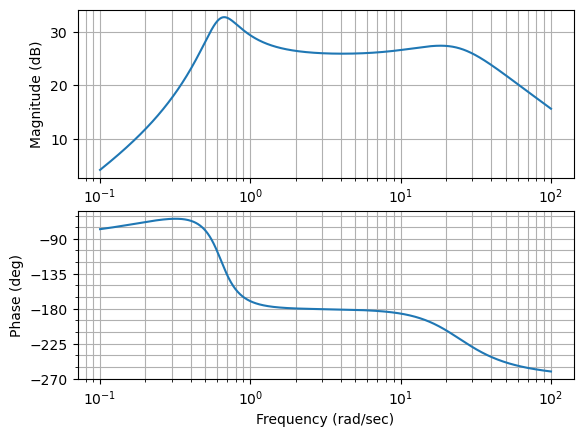

In [5]:
# --- Usage ---
# params = [CL0, CL_alpha, CD0, k_CD, CM0, CM_alpha, CM_Q, CM_e]
theta_true = np.array([0.2, 4.5, 0.04, 0.08, 0.02, -0.5, -8.0, -1.0])
tfs = get_aircraft_tfs(x0, u0, theta_true)

state_names = ['V', 'alpha', 'gamma', 'Q']
input_names = ['delta_T', 'delta_e']

# Unpack the three return values
tfs_dict, A_mat, B_mat = get_aircraft_tfs(x0, u0, theta_true)

state_names = ['V', 'alpha', 'gamma', 'Q']
input_names = ['delta_T', 'delta_e']

for u_name in input_names:
    for x_name in state_names:
        print(f"Transfer Function: {u_name} -> {x_name}")
        # Access using the names (keys) instead of [i][j]
        print(tfs_dict[u_name][x_name]) 
        print("-" * 40)

sys = tfs_dict['delta_e']['Q']

mag, phase, omega = ct.bode_plot(sys, dB=True)
plt.show()

Get FRFs

Using nperseg=256, noverlap=128 for N=480


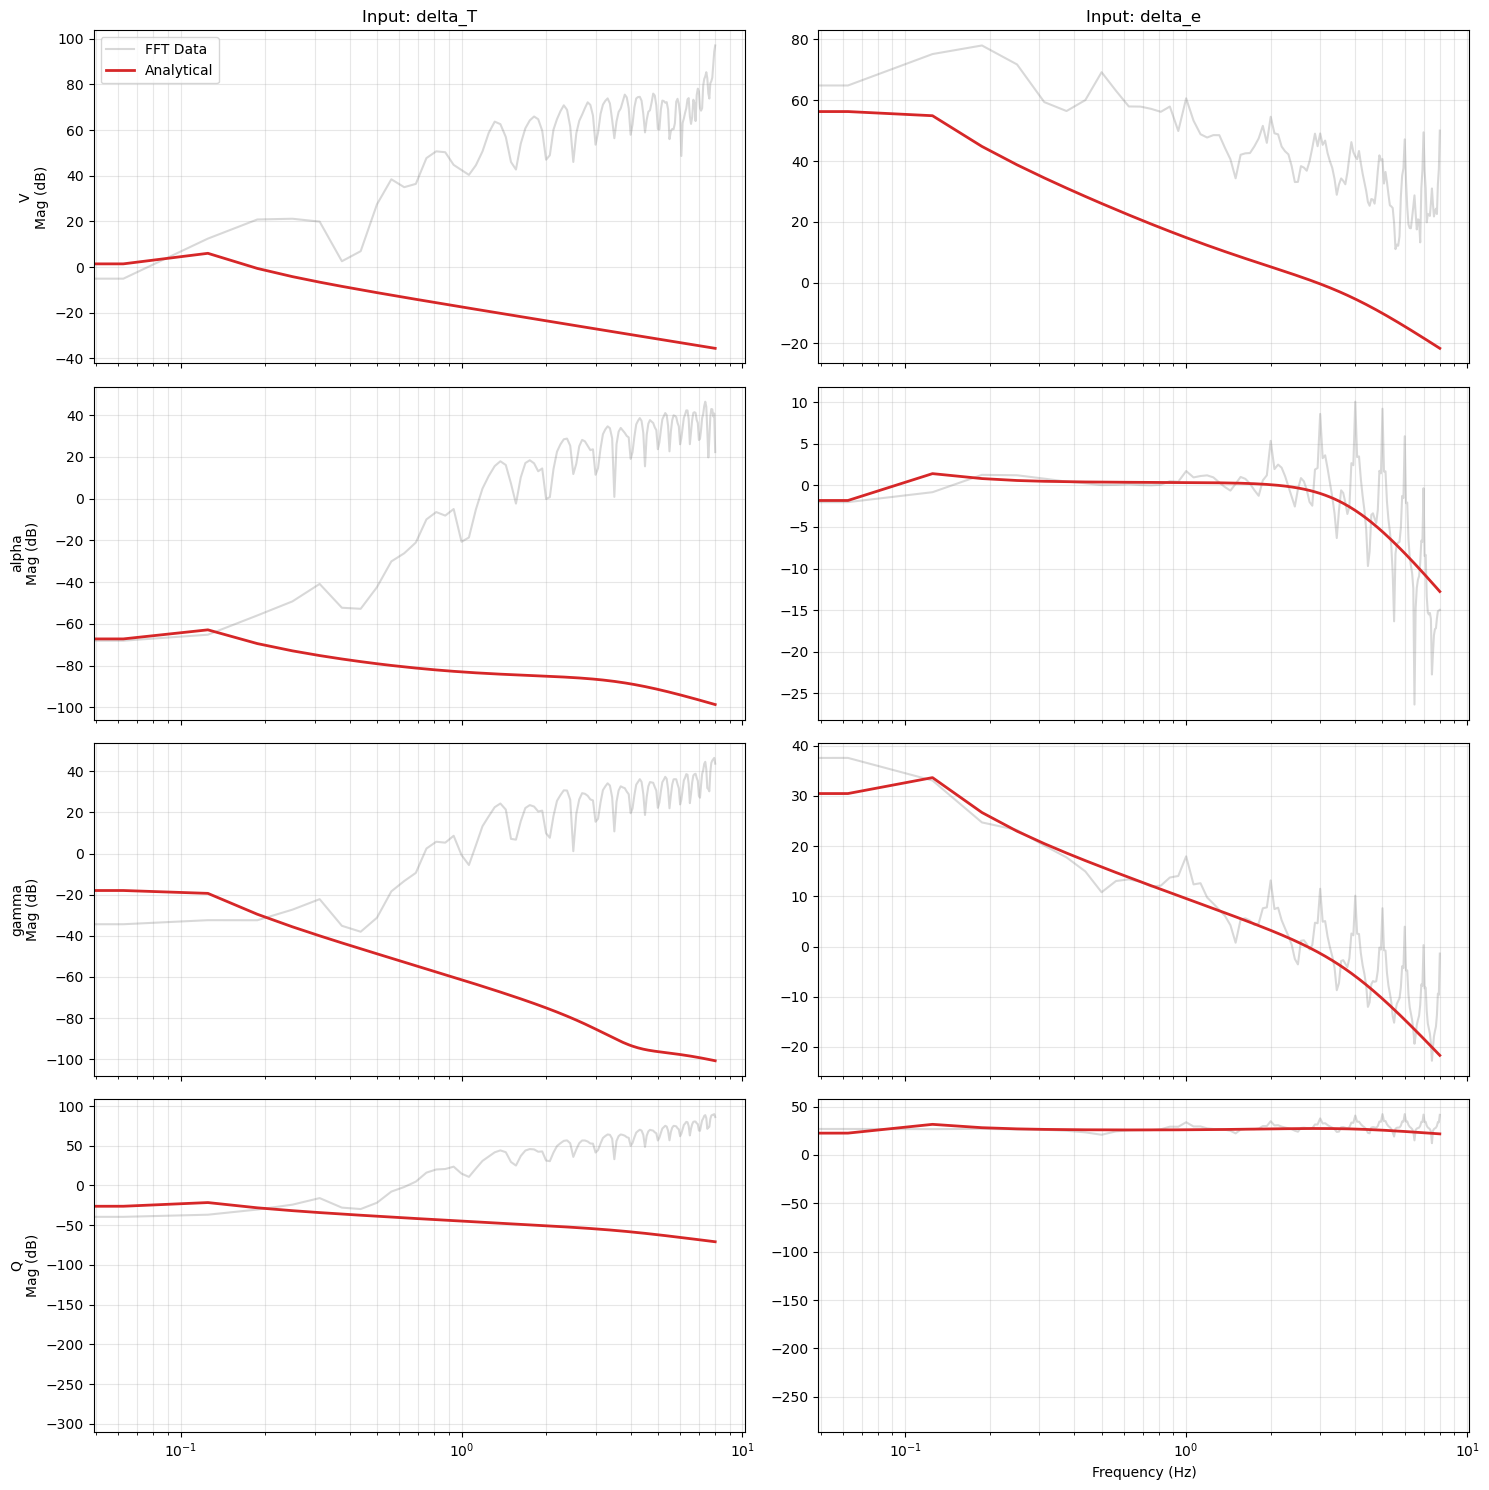

In [6]:
def compute_frfs(t, states, inputs, fs):
    # Determine segment length based on data size
    # We want a few segments to average, so we'll take 1/4 of total length 
    # but cap it at 1024 for frequency resolution.
    total_n = len(t)
    nperseg = min(total_n // 4, 1024) 
    
    # Ensure nperseg is at least a reasonable number (e.g., 256) for resolution
    nperseg = max(nperseg, 256) if total_n > 256 else total_n
    
    noverlap = nperseg // 2  # Standard 50% overlap
    
    print(f"Using nperseg={nperseg}, noverlap={noverlap} for N={total_n}")
    
    # 1. Get the frequency axis
    f, _ = welch(states[0], fs=fs, nperseg=nperseg, noverlap=noverlap)


    
    # Initialize containers: [output_idx, input_idx, frequency_idx]
    H_matrix = np.zeros((4, 2, len(f)), dtype=complex)
    coh_matrix = np.zeros((4, 2, len(f)))

    for j in range(2): # For each input (delta_T, delta_e)
        u = inputs[j]
        # Calculate Input PSD
        _, S_uu = welch(u, fs=fs, nperseg=nperseg, noverlap=noverlap)
        
        for i in range(4): # For each state (V, alpha, gamma, Q)
            y = states[i]
            
            # Calculate Cross-Spectral Density
            _, S_uy = csd(u, y, fs=fs, nperseg=nperseg, noverlap=noverlap)
            
            # Calculate FRF: H(jw) = Suy / Suu
            H_matrix[i, j, :] = S_uy / S_uu
            
            # Calculate Coherence (to know which data points to trust)
            _, S_yy = welch(y, fs=fs, nperseg=nperseg, noverlap=noverlap)
            coh_matrix[i, j, :] = (np.abs(S_uy)**2) / (S_uu * S_yy)

    return f, H_matrix, coh_matrix

# --- Usage ---
fs = 1.0 / (t[1] - t[0])  # Sampling frequency
states = [V, alpha, gamma, Q]
inputs = [delta_T, delta_e]

freqs_hz, H_data, coherence = compute_frfs(t, states, inputs, fs)
omega = 2 * np.pi * freqs_hz  # Convert to rad/s for fitting

def plot_analytical_vs_empirical(freqs_hz, H_data, tfs_dict):
    state_names = ['V', 'alpha', 'gamma', 'Q']
    input_names = ['delta_T', 'delta_e']
    
    # Convert Hz to rad/s for the control library
    w_vec = 2 * np.pi * freqs_hz
    
    fig, axes = plt.subplots(4, 2, figsize=(15, 15), sharex=True)
    
    for j, u_name in enumerate(input_names):
        for i, x_name in enumerate(state_names):
            ax = axes[i, j]
            
            # 1. Plot Empirical Data (FFT)
            mag_fft = 20 * np.log10(np.abs(H_data[i, j, :]) + 1e-9)
            ax.semilogx(freqs_hz, mag_fft, color='gray', alpha=0.3, label='FFT Data')
            
            # 2. Compute and Plot Analytical TF
            sys = tfs_dict[u_name][x_name]
            # mag is returned as absolute value, convert to dB
            mag_ana, _, _ = ct.freqresp(sys, w_vec)
            mag_ana_db = 20 * np.log10(mag_ana)
            
            ax.semilogx(freqs_hz, mag_ana_db, color='tab:red', lw=2, label='Analytical')
            
            # Formatting
            if i == 0: ax.set_title(f"Input: {u_name}")
            if j == 0: ax.set_ylabel(f"{x_name}\nMag (dB)")
            ax.grid(True, which="both", alpha=0.3)
            if i == 0 and j == 0: ax.legend()

    plt.xlabel("Frequency (Hz)")
    plt.tight_layout()
    plt.show()

    # --- Run the plot ---
plot_analytical_vs_empirical(freqs_hz, H_data, tfs_dict)

        

Fit transfer functions with least squares regression

In [7]:

def run_parameter_fit(freqs_hz, H_data, coherence, x0, u0, theta_init):
    # 1. Define the residuals function
    def residuals(params):
        # Build A and B for this specific guess
        A, B = linearise(x0, u0, params)
        
        # We'll fit in the "Pilot Band" (0.1 to 3.0 Hz)
        mask = (freqs_hz > 0.0001) & (freqs_hz < 3.0)
        w_fit = 2 * np.pi * freqs_hz[mask]
        
        res_vec = []
        
        # 8 Channels: 2 Inputs x 4 States
        for j in range(2): # delta_T, delta_e
            for i in range(4): # V, alpha, gamma, Q
                # Model response at all frequencies in the mask
                C = np.zeros((1, 4)); C[0, i] = 1
                sys = ct.ss(A, B[:, [j]], C, 0)
                mag_model, _, _ = ct.freqresp(sys, w_fit)
                
                # Empirical data
                mag_data = np.abs(H_data[i, j, mask])
                weight = coherence[i, j, mask]
                
                # Log-error ensures scale-invariant fitting
                # Adding 1e-6 prevents log(0)
                err = weight * (np.log(mag_data + 1e-6) - np.log(mag_model + 1e-6))
                res_vec.extend(err)
                
        return np.array(res_vec)
    
   # 2. Execute Least Squares
    # Bounds keep the physics realistic (e.g., Lift slopes must be positive)
    res = least_squares(residuals, theta_init, 
                    bounds=([0.1, 3.0, 0.02, 0.05, -0.05, -1.0, -15.0, -2.0], 
                            [0.3, 6.0, 0.06, 0.15,  0.05, -0.1, -2.0,  -0.5]))
    return res.x


        
     

# Run it
theta_estimated = run_parameter_fit(freqs_hz, H_data, coherence, x0, u0, theta_true)

param_names = ["CL0", "CL_alpha", "CD0", "k_CD", "CM0", "CM_alpha", "CM_Q", "CM_e"]
print(f"{'Param':<10} | {'True':<8} | {'Estimated':<10} | {'% Error':<8}")
print("-" * 45)

for name, i, e in zip(param_names, theta_true, theta_estimated):
    err = abs((e - i) / i) * 100
    print(f"{name:<10} | {i:<8.3f} | {e:<10.3f} | {err:<8.1f}%")    
    

Param      | True     | Estimated  | % Error 
---------------------------------------------
CL0        | 0.200    | 0.300      | 50.0    %
CL_alpha   | 4.500    | 4.341      | 3.5     %
CD0        | 0.040    | 0.059      | 48.0    %
k_CD       | 0.080    | 0.150      | 87.5    %
CM0        | 0.020    | 0.050      | 150.0   %
CM_alpha   | -0.500   | -0.254     | 49.2    %
CM_Q       | -8.000   | -2.000     | 75.0    %
CM_e       | -1.000   | -1.044     | 4.4     %


Simulate responses

[ 0.         -0.00095699 -0.00159405 -0.00200583 -0.00227766 -0.0024798
 -0.00266503 -0.00286869 -0.00311028 -0.00339607 -0.00372227 -0.00407837
 -0.00445026 -0.00482284 -0.00518193 -0.00551534 -0.00581321 -0.00606786
 -0.0062733  -0.00642467 -0.00651789 -0.00654946 -0.00651649 -0.0064169
 -0.00624965 -0.00601498 -0.00571456 -0.00535153 -0.00493052 -0.00445756
 -0.00393989 -0.0033858  -0.00280439 -0.00231945 -0.00227931 -0.00264609
 -0.00322726 -0.00388395 -0.00456378 -0.00526722 -0.00601141 -0.00681136
 -0.00767549 -0.00860727 -0.00960749 -0.01067546 -0.01180919 -0.01300517
 -0.01425828 -0.01556176 -0.01690733 -0.01828531 -0.01968489 -0.0210943
 -0.02250115 -0.02389276 -0.02525645 -0.02657999 -0.02785192 -0.02906196
 -0.03020131 -0.03126299 -0.03224209 -0.03313599 -0.03394446 -0.03466975
 -0.03531659 -0.03589207 -0.03640553 -0.03686829 -0.0372934  -0.0376953
 -0.03808944 -0.03849183 -0.03891869 -0.03938591 -0.03990868 -0.040501
 -0.04117529 -0.04194198 -0.0428092  -0.04283276 -0.03929

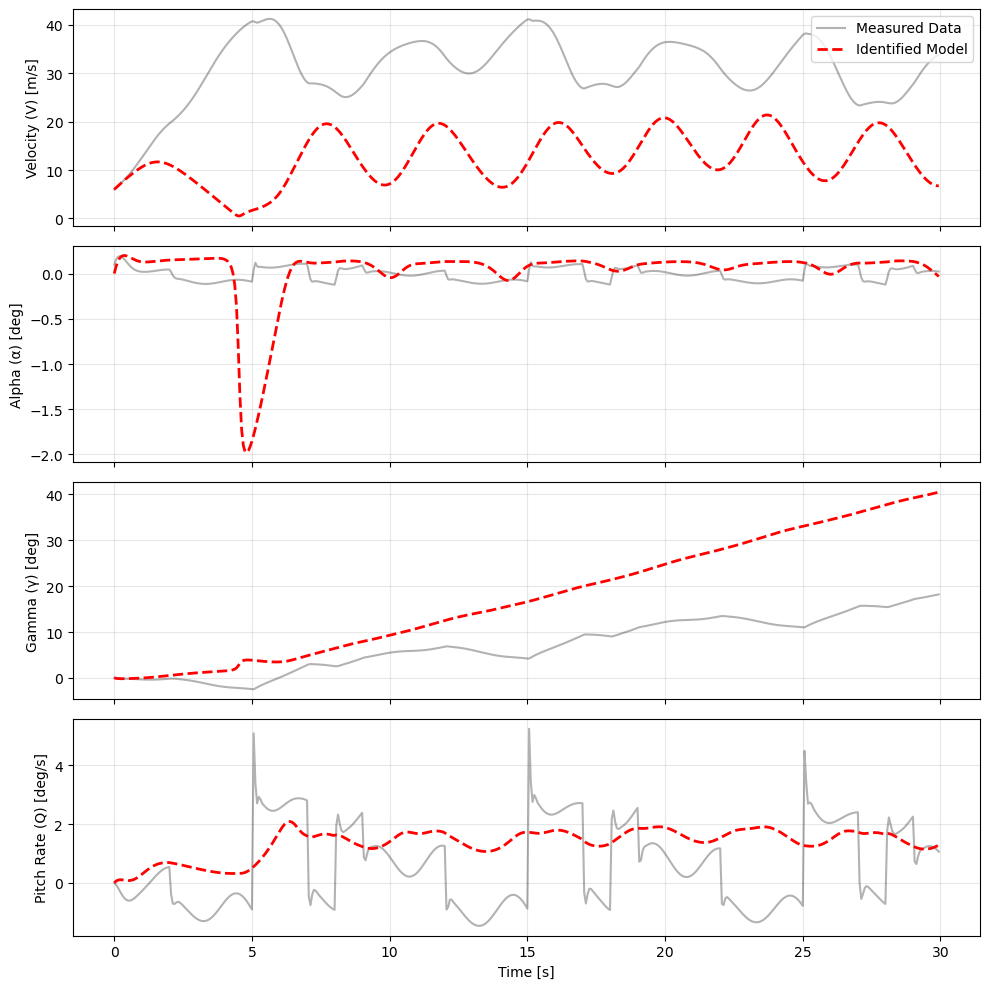

In [8]:
def simulate(t_vec, v0, alpha0, gamma0, q0, u_T, u_e, params):
    from scipy.integrate import solve_ivp

    # Unpack the 8 aerodynamic parameters
    CL0, CL_a, CD0, k_CD, CM0, CM_a, CM_Q, CM_e = params

    def ode_dynamics(t_cur, x):
        V_, a_, g_, Q_ = x
        
        # Interpolate the measured control inputs at the current integrator time
        T_  = np.interp(t_cur, t_vec, u_T)
        de_ = np.interp(t_cur, t_vec, u_e)

        # Protection against divide-by-zero
        V_safe = max(V_, 1e-3)
        
        # Aerodynamics
        CL = CL0 + CL_a * a_
        CD = CD0 + k_CD * CL**2
        qhat_local = cbar * Q_ / (2 * V_safe)
        CM = CM0 + CM_a * a_ + CM_Q * qhat_local + CM_e * de_

        # Forces and Moments
        qdyn = 0.5 * rho * V_safe**2
        L = qdyn * S * CL
        D = qdyn * S * CD
        M = qdyn * S * cbar * CM

        # Equations of Motion
        Vdot_     = (-D + T_*np.cos(a_) - m*g*np.sin(g_)) / m
        gammadot_ = ( L + T_*np.sin(a_) - m*g*np.cos(g_)) / (m * V_safe)
        Qdot_     = M / Jy
        alphadot_ = Q_ - gammadot_
        
        return [Vdot_, alphadot_, gammadot_, Qdot_]
    # Run the integrator
    sol = solve_ivp(
        ode_dynamics, 
        [t_vec[0], t_vec[-1]], 
        [v0, alpha0, gamma0, q0],
        t_eval=t_vec, 
        method='RK45',
        rtol=1e-6, 
        atol=1e-8
    )
    return sol
# 1. Run the simulation with estimated parameters
sol_sim = simulate(t, V[0], alpha[0], gamma[0], Q[0], 
                   delta_T, delta_e, theta_estimated)

# 2. Plotting
fig, axes = plt.subplots(4, 1, figsize=(10, 10), sharex=True)
labels = ["Velocity (V) [m/s]", "Alpha (α) [deg]", 
          "Gamma (γ) [deg]", "Pitch Rate (Q) [deg/s]"]
measured_data = [V, np.degrees(alpha), np.degrees(gamma), np.degrees(Q)]
print(gamma)
print(t)

for i in range(4):
    axes[i].plot(t, measured_data[i], 'k', alpha=0.3, label="Measured Data")
    axes[i].plot(sol_sim.t, sol_sim.y[i], 'r--', lw=2, label="Identified Model")
    axes[i].set_ylabel(labels[i])
    axes[i].grid(True, alpha=0.3)
    if i == 0:
        axes[i].legend(loc='upper right')

plt.xlabel("Time [s]")
plt.tight_layout()
plt.show()

Full code

Transfer Function: delta_T -> V

  0.8333 s^3 + 27.67 s^2 + 474.6 s - 8.785
---------------------------------------------
s^4 + 33.55 s^3 + 580.6 s^2 + 193.7 s + 230.1

----------------------------------------
Transfer Function: delta_T -> alpha

-5.228e-06 s^3 - 0.02984 s^2 + 0.1708 s - 0.02224
-------------------------------------------------
  s^4 + 33.55 s^3 + 580.6 s^2 + 193.7 s + 230.1

----------------------------------------
Transfer Function: delta_T -> gamma

5.228e-06 s^3 + 0.02984 s^2 + 0.4548 s + 20.04
----------------------------------------------
s^4 + 33.55 s^3 + 580.6 s^2 + 193.7 s + 230.1

----------------------------------------
Transfer Function: delta_T -> Q

4.263e-14 s^3 + 0.6256 s^2 + 20.02 s + 6.253e-13
------------------------------------------------
 s^4 + 33.55 s^3 + 580.6 s^2 + 193.7 s + 230.1

----------------------------------------
Transfer Function: delta_e -> V

  -6.821e-13 s^2 + 1.054e+04 s + 1.034e+05
---------------------------------------------
s^

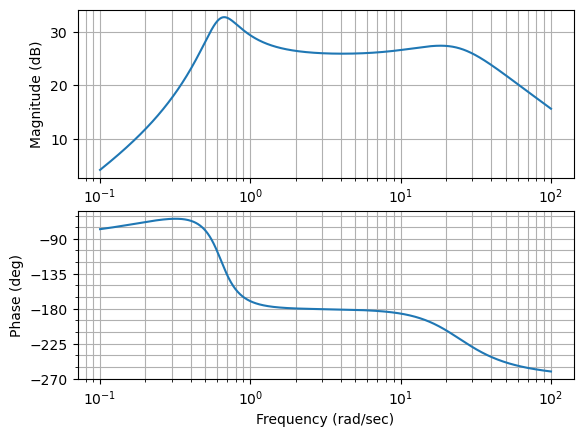

Using nperseg=256, noverlap=128 for N=480


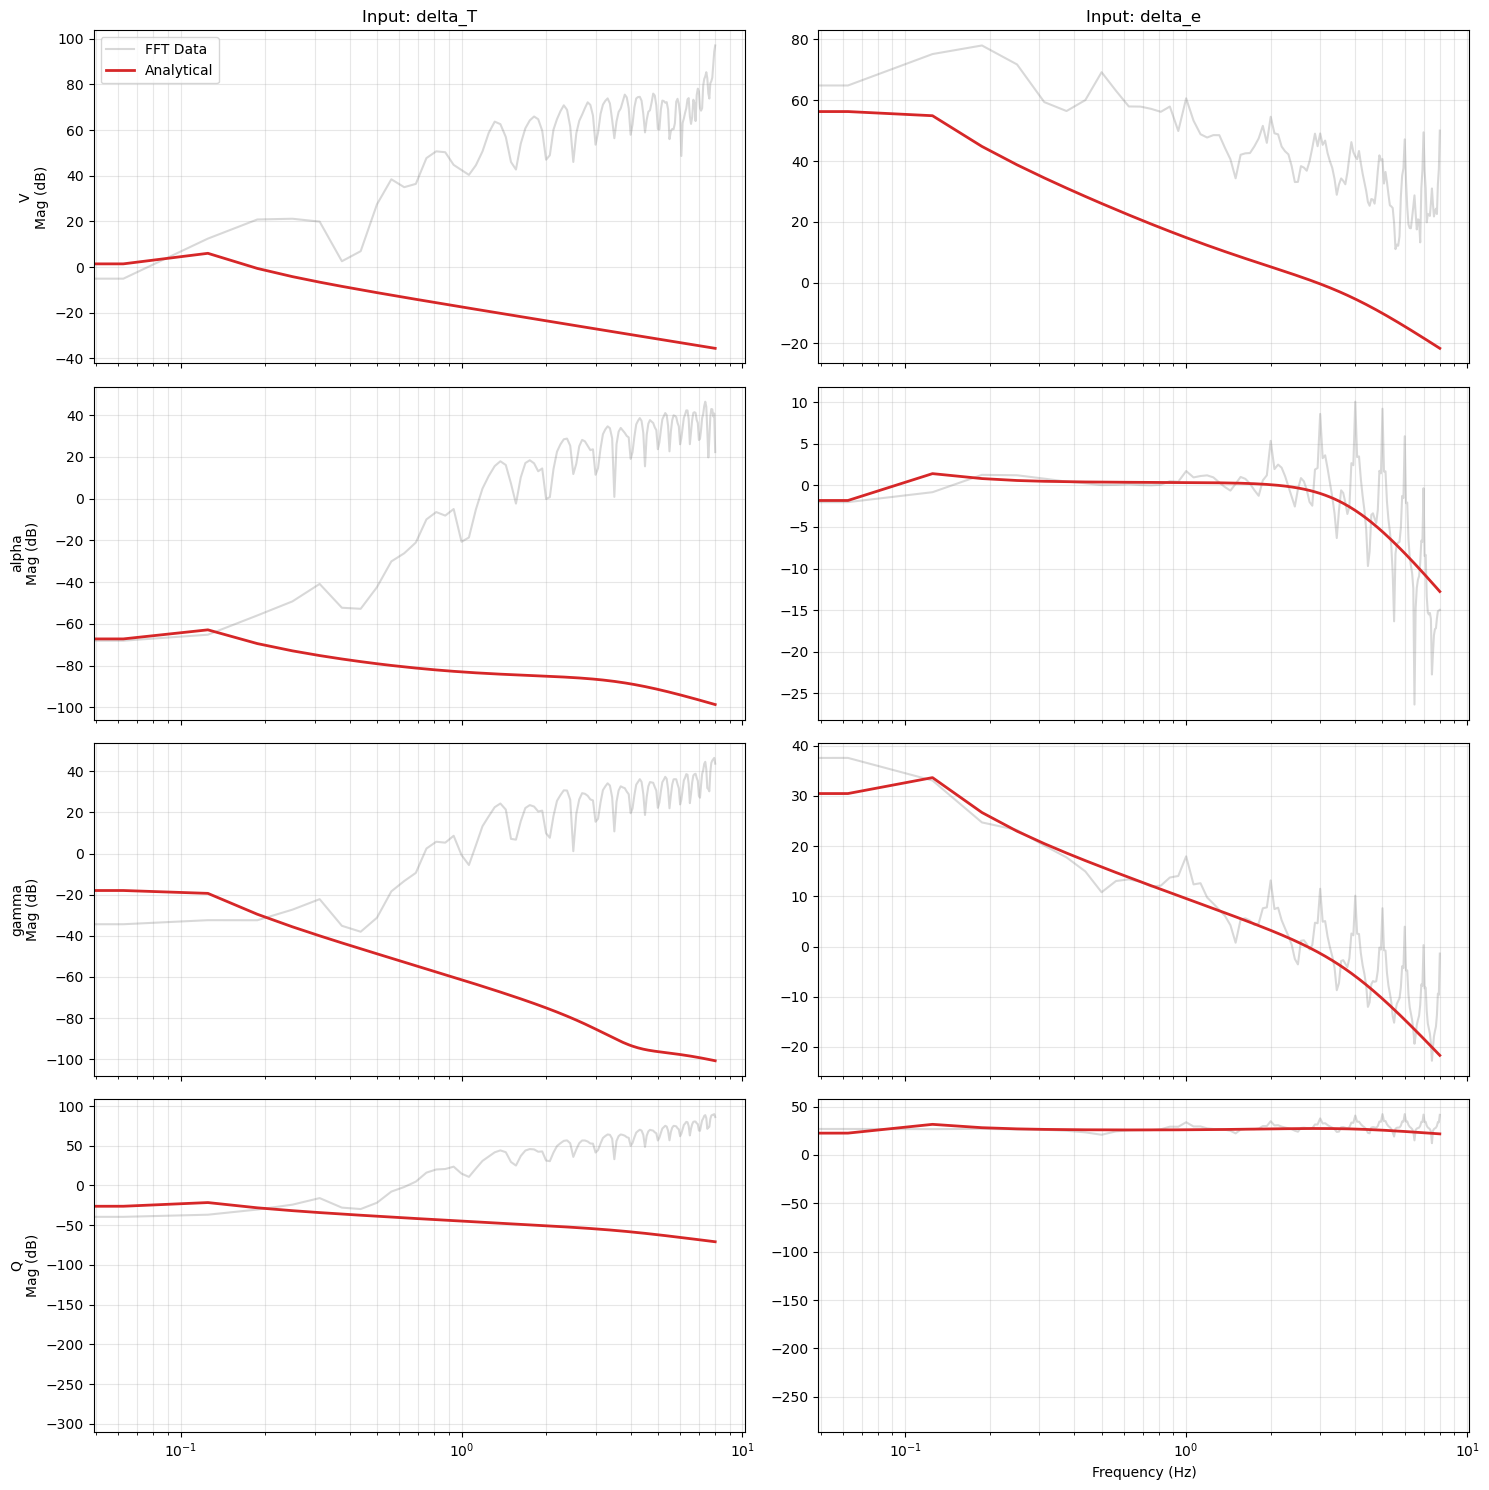

Param      | True     | Estimated  | % Error 
---------------------------------------------
CL0        | 0.200    | 0.300      | 50.0    %
CL_alpha   | 4.500    | 4.078      | 9.4     %
CD0        | 0.040    | 0.060      | 50.0    %
k_CD       | 0.080    | 0.150      | 87.5    %
CM0        | 0.020    | 0.050      | 150.0   %
CM_alpha   | -0.500   | -0.303     | 39.3    %
CM_Q       | -8.000   | -2.012     | 74.8    %
CM_e       | -1.000   | -1.036     | 3.6     %


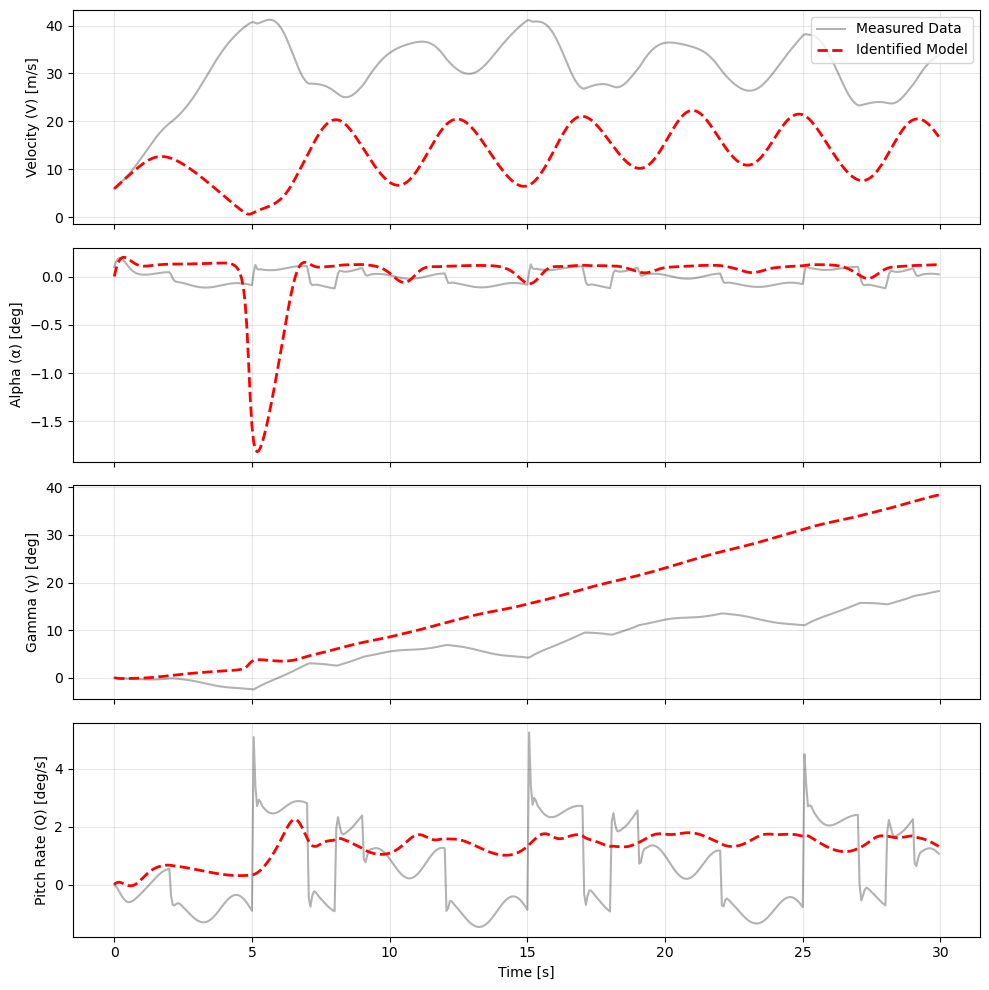

In [9]:

def wrap_angle(x):
    """Wrap angle(s) in radians to (-pi, pi]."""
    return (x + np.pi) % (2 * np.pi) - np.pi

# Load the data and unpack columns into variables
t, V, alpha, gamma, Q, delta_T, delta_e = np.loadtxt(
    'flight_data.txt', 
    unpack=True
)

alpha   = np.radians(alpha)
gamma   = np.radians(gamma)
Q       = np.radians(Q)
delta_e = np.radians(delta_e)

#real parameters of aircraft
g=9.8; rho=1.225; S=0.25; cbar=0.2; m=1.2; Jy=0.05

# ── Load data (replace with your arrays) ──────────────────────────────
# t, V, alpha, gamma, Q, delta_T, delta_e

N  = len(t)
dt = t[1] - t[0]

def deriv(x): return np.gradient(x, dt)
def W(x):     return x * np.hanning(N)   # windowed FFT
def F(x):     return fft(W(x))

freqs = fftfreq(N, dt)

Vdot     = deriv(V)
alphadot = deriv(alpha)
gammadot = deriv(gamma)
Qdot     = deriv(Q)
qhat     = cbar * Q / (2 * V)
q_dyn    = 0.5 * rho * V**2

x0 = np.array([
    np.median(V),
    np.median(alpha),
    np.median(wrap_angle(gamma)),
    np.median(Q)
])
u0 = np.array([
    np.median(delta_T),
    np.median(delta_e)
])

def dynamics(x, u, params):
    V, alpha, gamma, Q       = x
    delta_T, delta_e         = u
    CL0, CL_alpha, CD0, k_CD, CM0, CM_alpha, CM_Q, CM_e = params

    V_safe = max(V, 1e-3)
    qhat   = cbar * Q / (2 * V_safe)

    CL = CL0 + CL_alpha * alpha
    CD = CD0 + k_CD * CL**2
    CM = CM0 + CM_alpha * alpha + CM_Q * qhat + CM_e * delta_e

    q_dyn = 0.5 * rho * V**2
    L     = q_dyn * S * CL
    D     = q_dyn * S * CD
    M     = q_dyn * S * cbar * CM
    T     = delta_T

    Vdot     = (-D + T*np.cos(alpha) - m*g*np.sin(gamma)) / m
    gammadot = ( L + T*np.sin(alpha) - m*g*np.cos(gamma)) / (m * V_safe)
    Qdot     = M / Jy
    alphadot = Q - gammadot

    return np.array([Vdot, alphadot, gammadot, Qdot])



def linearise(x0, u0, params, eps=1e-6):
    """
    Computes the A and B matrices for the system dot{x} = Ax + Bu
    around the equilibrium point (x0, u0) using central differences.
    """
    nx = len(x0)
    nu = len(u0)
    
    A = np.zeros((nx, nx))
    B = np.zeros((nx, nu))
    
    # --- Compute A matrix (df/dx) ---
    # We nudge each state variable one by one
    for i in range(nx):
        x_plus = x0.copy()
        x_minus = x0.copy()
        
        x_plus[i] += eps
        x_minus[i] -= eps
        
        # Central difference formula: (f(x+eps) - f(x-eps)) / (2*eps)
        f_plus = dynamics(x_plus, u0, params)
        f_minus = dynamics(x_minus, u0, params)
        
        A[:, i] = (f_plus - f_minus) / (2 * eps)
        
    # --- Compute B matrix (df/du) ---
    # We nudge each input variable one by one
    for j in range(nu):
        u_plus = u0.copy()
        u_minus = u0.copy()
        
        u_plus[j] += eps
        u_minus[j] -= eps
        
        f_plus = dynamics(x0, u_plus, params)
        f_minus = dynamics(x0, u_minus, params)
        
        B[:, j] = (f_plus - f_minus) / (2 * eps)
        
    return A, B

def get_aircraft_tfs(x0, u0, params):
    A, B = linearise(x0, u0, params)
    nx, nu = B.shape
    
    # Pre-define names for clarity
    state_names = ['V', 'alpha', 'gamma', 'Q']
    input_names = ['delta_T', 'delta_e']
    
    tf_matrix = {} # Using a dict for easier access: tfs['delta_e']['Q']
    
    for j in range(nu):
        u_name = input_names[j]
        tf_matrix[u_name] = {}
        
        for i in range(nx):
            x_name = state_names[i]
            
            # SISO selection
            C_single = np.zeros((1, nx))
            C_single[0, i] = 1
            B_single = B[:, [j]]
            
            # Create system - Note: D is usually 0 in aircraft dynamics
            sys_siso = ct.ss(A, B_single, C_single, 0)
            
            # Clean up the TF: removes tiny numerical noise (e.g., 1e-18)
            tf = ct.tf(sys_siso)
            tf_matrix[u_name][x_name] = tf
            
    return tf_matrix, A, B

# --- Usage ---
# params = [CL0, CL_alpha, CD0, k_CD, CM0, CM_alpha, CM_Q, CM_e]
theta_true = np.array([0.2, 4.5, 0.04, 0.08, 0.02, -0.5, -8.0, -1.0])
tfs = get_aircraft_tfs(x0, u0, theta_true)

state_names = ['V', 'alpha', 'gamma', 'Q']
input_names = ['delta_T', 'delta_e']

# Unpack the three return values
tfs_dict, A_mat, B_mat = get_aircraft_tfs(x0, u0, theta_true)

state_names = ['V', 'alpha', 'gamma', 'Q']
input_names = ['delta_T', 'delta_e']

for u_name in input_names:
    for x_name in state_names:
        print(f"Transfer Function: {u_name} -> {x_name}")
        # Access using the names (keys) instead of [i][j]
        print(tfs_dict[u_name][x_name]) 
        print("-" * 40)

sys = tfs_dict['delta_e']['Q']

mag, phase, omega = ct.bode_plot(sys, dB=True)
plt.show()

def compute_frfs(t, states, inputs, fs):
    # Determine segment length based on data size
    # We want a few segments to average, so we'll take 1/4 of total length 
    # but cap it at 1024 for frequency resolution.
    total_n = len(t)
    nperseg = min(total_n // 4, 1024) 
    
    # Ensure nperseg is at least a reasonable number (e.g., 256) for resolution
    nperseg = max(nperseg, 256) if total_n > 256 else total_n
    
    noverlap = nperseg // 2  # Standard 50% overlap
    
    print(f"Using nperseg={nperseg}, noverlap={noverlap} for N={total_n}")
    
    # 1. Get the frequency axis
    f, _ = welch(states[0], fs=fs, nperseg=nperseg, noverlap=noverlap)


    
    # Initialize containers: [output_idx, input_idx, frequency_idx]
    H_matrix = np.zeros((4, 2, len(f)), dtype=complex)
    coh_matrix = np.zeros((4, 2, len(f)))

    for j in range(2): # For each input (delta_T, delta_e)
        u = inputs[j]
        # Calculate Input PSD
        _, S_uu = welch(u, fs=fs, nperseg=nperseg, noverlap=noverlap)
        
        for i in range(4): # For each state (V, alpha, gamma, Q)
            y = states[i]
            
            # Calculate Cross-Spectral Density
            _, S_uy = csd(u, y, fs=fs, nperseg=nperseg, noverlap=noverlap)
            
            # Calculate FRF: H(jw) = Suy / Suu
            H_matrix[i, j, :] = S_uy / S_uu
            
            # Calculate Coherence (to know which data points to trust)
            _, S_yy = welch(y, fs=fs, nperseg=nperseg, noverlap=noverlap)
            coh_matrix[i, j, :] = (np.abs(S_uy)**2) / (S_uu * S_yy)

    return f, H_matrix, coh_matrix

# --- Usage ---
fs = 1.0 / (t[1] - t[0])  # Sampling frequency
states = [V, alpha, gamma, Q]
inputs = [delta_T, delta_e]

freqs_hz, H_data, coherence = compute_frfs(t, states, inputs, fs)
omega = 2 * np.pi * freqs_hz  # Convert to rad/s for fitting





def plot_analytical_vs_empirical(freqs_hz, H_data, tfs_dict):
    state_names = ['V', 'alpha', 'gamma', 'Q']
    input_names = ['delta_T', 'delta_e']
    
    # Convert Hz to rad/s for the control library
    w_vec = 2 * np.pi * freqs_hz
    
    fig, axes = plt.subplots(4, 2, figsize=(15, 15), sharex=True)
    
    for j, u_name in enumerate(input_names):
        for i, x_name in enumerate(state_names):
            ax = axes[i, j]
            
            # 1. Plot Empirical Data (FFT)
            mag_fft = 20 * np.log10(np.abs(H_data[i, j, :]) + 1e-9)
            ax.semilogx(freqs_hz, mag_fft, color='gray', alpha=0.3, label='FFT Data')
            
            # 2. Compute and Plot Analytical TF
            sys = tfs_dict[u_name][x_name]
            # mag is returned as absolute value, convert to dB
            mag_ana, _, _ = ct.freqresp(sys, w_vec)
            mag_ana_db = 20 * np.log10(mag_ana)
            
            ax.semilogx(freqs_hz, mag_ana_db, color='tab:red', lw=2, label='Analytical')
            
            # Formatting
            if i == 0: ax.set_title(f"Input: {u_name}")
            if j == 0: ax.set_ylabel(f"{x_name}\nMag (dB)")
            ax.grid(True, which="both", alpha=0.3)
            if i == 0 and j == 0: ax.legend()

    plt.xlabel("Frequency (Hz)")
    plt.tight_layout()
    plt.show()

# --- Run the plot ---
plot_analytical_vs_empirical(freqs_hz, H_data, tfs_dict)



def run_parameter_fit(freqs_hz, H_data, coherence, x0, u0, theta_init):
    # 1. Define the residuals function
    def residuals(params):
        # Build A and B for this specific guess
        A, B = linearise(x0, u0, params)
        
        # We'll fit in the "Pilot Band" (0.1 to 3.0 Hz)
        mask = (freqs_hz > 0.01) & (freqs_hz < 3.0)
        w_fit = 2 * np.pi * freqs_hz[mask]
        
        res_vec = []
        # 8 Channels: 2 Inputs x 4 States
        for j in range(2): # delta_T, delta_e
            for i in range(4): # V, alpha, gamma, Q
                # Model response at all frequencies in the mask
                C = np.zeros((1, 4)); C[0, i] = 1
                sys = ct.ss(A, B[:, [j]], C, 0)
                mag_model, _, _ = ct.freqresp(sys, w_fit)
                
                # Empirical data
                mag_data = np.abs(H_data[i, j, mask])
                weight = coherence[i, j, mask]
                
                # Log-error ensures scale-invariant fitting
                # Adding 1e-6 prevents log(0)
                err = weight * (np.log(mag_data + 1e-6) - np.log(mag_model + 1e-6))
                res_vec.extend(err)
                
        return np.array(res_vec)
    # 2. Execute Least Squares
    # Bounds keep the physics realistic (e.g., Lift slopes must be positive)
    res = least_squares(residuals, theta_init, 
                    bounds=([0.1, 3.0, 0.02, 0.05, -0.05, -1.0, -15.0, -2.0], 
                            [0.3, 6.0, 0.06, 0.15,  0.05, -0.1, -2.0,  -0.5]))
    return res.x


def run_better_freq_domain_fit(freqs_hz, H_data, coherence, x0, u0, theta_init):
    # Weight for Phase vs Magnitude (1.0 = equal)
    phase_weight = 0.5 

    def residuals(params):
        A, B = linearise(x0, u0, params)
        # Wider mask to capture quasi-steady behavior
        mask = (freqs_hz > 0.01) & (freqs_hz < 3.0)
        w_fit = 2 * np.pi * freqs_hz[mask]
        
        res_vec = []
        for j in range(2): # Inputs
            for i in range(4): # States
                C = np.zeros((1, 4)); C[0, i] = 1
                sys = ct.ss(A, B[:, [j]], C, 0)
                
                # Get complex response: H(jw)
                mag_model, phase_model, _ = ct.freqresp(sys, w_fit)
                mag_data = np.abs(H_data[i, j, mask])
                phase_data = np.angle(H_data[i, j, mask])
                
                # Reliability weight
                W = coherence[i, j, mask]**2
                
                # 1. Magnitude error (Log scale for gain-invariance)
                mag_err = W * (np.log(mag_data + 1e-6) - np.log(mag_model + 1e-6))
                
                # 2. Phase error (Wrapped to avoid 360-degree jumps)
                phase_err = W * phase_weight * np.arctan2(
                    np.sin(phase_data - phase_model), 
                    np.cos(phase_data - phase_model)
                )
                
                res_vec.extend(mag_err)
                res_vec.extend(phase_err)
                
        return np.array(res_vec)

    res = least_squares(
        residuals, 
        theta_init, 
        method='trf',
        bounds=([0.1, 3.0, 0.02, 0.05, -0.05, -1.0, -15.0, -2.0], 
                [0.3, 6.0, 0.06, 0.15,  0.05, -0.1, -2.0,  -0.5])
    )
    return res.x        
     

# Run it
#theta_estimated = run_parameter_fit(freqs_hz, H_data, coherence, x0, u0, theta_true)
theta_estimated = run_better_freq_domain_fit(freqs_hz, H_data, coherence, x0, u0, theta_true)

param_names = ["CL0", "CL_alpha", "CD0", "k_CD", "CM0", "CM_alpha", "CM_Q", "CM_e"]
print(f"{'Param':<10} | {'True':<8} | {'Estimated':<10} | {'% Error':<8}")
print("-" * 45)

for name, i, e in zip(param_names, theta_true, theta_estimated):
    err = abs((e - i) / i) * 100
    print(f"{name:<10} | {i:<8.3f} | {e:<10.3f} | {err:<8.1f}%")


def simulate(t_vec, v0, alpha0, gamma0, q0, u_T, u_e, params):
    from scipy.integrate import solve_ivp

    # Unpack the 8 aerodynamic parameters
    CL0, CL_a, CD0, k_CD, CM0, CM_a, CM_Q, CM_e = params

    def ode_dynamics(t_cur, x):
        V_, a_, g_, Q_ = x
        
        # Interpolate the measured control inputs at the current integrator time
        T_  = np.interp(t_cur, t_vec, u_T)
        de_ = np.interp(t_cur, t_vec, u_e)

        # Protection against divide-by-zero
        V_safe = max(V_, 1e-3)
        
        # Aerodynamics
        CL = CL0 + CL_a * a_
        CD = CD0 + k_CD * CL**2
        qhat_local = cbar * Q_ / (2 * V_safe)
        CM = CM0 + CM_a * a_ + CM_Q * qhat_local + CM_e * de_

        # Forces and Moments
        qdyn = 0.5 * rho * V_safe**2
        L = qdyn * S * CL
        D = qdyn * S * CD
        M = qdyn * S * cbar * CM

        # Equations of Motion
        Vdot_     = (-D + T_*np.cos(a_) - m*g*np.sin(g_)) / m
        gammadot_ = ( L + T_*np.sin(a_) - m*g*np.cos(g_)) / (m * V_safe)
        Qdot_     = M / Jy
        alphadot_ = Q_ - gammadot_
        
        return [Vdot_, alphadot_, gammadot_, Qdot_]

    # Run the integrator
    sol = solve_ivp(
        ode_dynamics, 
        [t_vec[0], t_vec[-1]], 
        [v0, alpha0, gamma0, q0],
        t_eval=t_vec, 
        method='RK45',
        rtol=1e-6, 
        atol=1e-8
    )
    return sol
# 1. Run the simulation with estimated parameters
sol_sim = simulate(t, V[0], alpha[0], gamma[0], Q[0], 
                   delta_T, delta_e, theta_estimated)

# 2. Plotting
fig, axes = plt.subplots(4, 1, figsize=(10, 10), sharex=True)
labels = ["Velocity (V) [m/s]", "Alpha (α) [deg]", 
          "Gamma (γ) [deg]", "Pitch Rate (Q) [deg/s]"]
measured_data = [V, np.degrees(alpha), np.degrees(gamma), np.degrees(Q)]

for i in range(4):
    axes[i].plot(t, measured_data[i], 'k', alpha=0.3, label="Measured Data")
    axes[i].plot(sol_sim.t, sol_sim.y[i], 'r--', lw=2, label="Identified Model")
    axes[i].set_ylabel(labels[i])
    axes[i].grid(True, alpha=0.3)
    if i == 0:
        axes[i].legend(loc='upper right')

plt.xlabel("Time [s]")
plt.tight_layout()
plt.show()

   
 





Bode plot

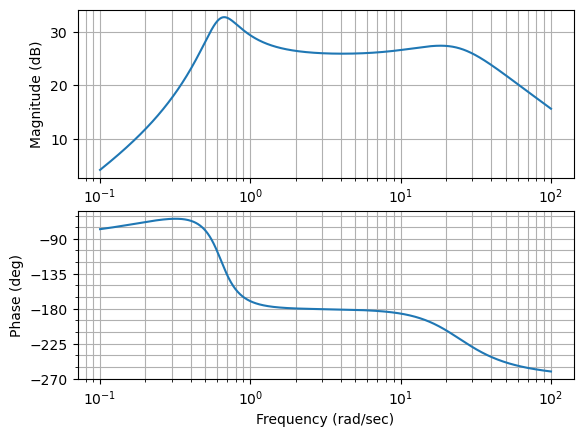

In [10]:
sys = tfs_dict['delta_e']['Q']

mag, phase, omega = ct.bode_plot(sys, dB=True)
plt.show()